In [1]:
import os
import json
import random
import time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPUs: []


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd()
PROJECT_ROOT = ROOT / "19042026"

ALBANIAN_IMG_DIR = ROOT / "Albanian_Images"
ALBANIAN_METADATA = ROOT / "Albanian_Images_Data.xlsx"

EXP_ROOT = PROJECT_ROOT / "Albanian_local_training_testing"

IMG_SIZE = (224, 224)
THRESHOLD = 0.55

USE_HAIR_REMOVAL = True
USE_SEGMENTATION = True
AUG_MODE = "strong"

DENSE_UNITS = 256
DROPOUT = 0.4
LR = 5e-05
BATCH_SIZE = 16
EPOCHS = 15

SUBDIRS = [
    "models",
    "histories",
    "metrics",
    "predictions",
    "plots",
    "confusion_matrix",
    "feature_cache",
    "summary",
    "preprocessing_samples"
]

for sub in SUBDIRS:
    (EXP_ROOT / sub).mkdir(parents=True, exist_ok=True)

print("Experiment folder:", EXP_ROOT)

Experiment folder: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\Albanian_local_training_testing


In [3]:
def remove_hairs_bgr(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img_bgr, mask, 1, cv2.INPAINT_TELEA)
    return cleaned, mask

def simple_segment_lesion(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return img_bgr, thresh

    largest = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest], -1, 255, thickness=-1)

    segmented = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    x, y, w, h = cv2.boundingRect(largest)
    crop = segmented[y:y+h, x:x+w] if w > 0 and h > 0 else segmented

    return crop, mask

def apply_augmentation(img_rgb, mode="strong"):
    h, w = img_rgb.shape[:2]

    if random.random() < 0.5:
        img_rgb = cv2.flip(img_rgb, 1)

    angle = random.uniform(-30, 30)
    scale = random.uniform(0.85, 1.15)
    tx = random.uniform(-0.08*w, 0.08*w)
    ty = random.uniform(-0.08*h, 0.08*h)
    alpha = random.uniform(0.85, 1.15)
    beta = random.uniform(-20, 20)

    M = cv2.getRotationMatrix2D((w//2, h//2), angle, scale)
    M[:, 2] += [tx, ty]

    img_rgb = cv2.warpAffine(img_rgb, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    img_rgb = cv2.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)

    return img_rgb

def preprocess_image(path, use_aug=False):
    img_bgr = cv2.imread(str(path))

    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    original = img_bgr.copy()
    hair_mask = None
    seg_mask = None

    if USE_HAIR_REMOVAL:
        img_bgr, hair_mask = remove_hairs_bgr(img_bgr)

    if USE_SEGMENTATION:
        img_bgr, seg_mask = simple_segment_lesion(img_bgr)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)

    if use_aug:
        img_rgb = apply_augmentation(img_rgb, mode=AUG_MODE)

    img_arr = np.asarray(img_rgb, dtype=np.float32)
    img_arr = preprocess_input(img_arr)

    return img_arr, original, hair_mask, seg_mask

In [4]:
metadata_df = pd.read_excel(ALBANIAN_METADATA)
metadata_df.columns = [c.strip() for c in metadata_df.columns]

if "Image" not in metadata_df.columns or "Result" not in metadata_df.columns:
    raise ValueError("Metadata must contain columns: Image and Result")

valid_exts = [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]

records = []

for _, row in metadata_df.iterrows():
    image_id = str(row["Image"]).strip()
    label = int(row["Result"])

    found_path = None

    for ext in valid_exts:
        candidate = ALBANIAN_IMG_DIR / f"{image_id}{ext}"
        if candidate.exists():
            found_path = candidate
            break

    records.append({
        "image_name": image_id,
        "image_path": found_path,
        "target": label,
        "status": "found" if found_path is not None else "missing"
    })

df = pd.DataFrame(records)

print(df["status"].value_counts())
display(df.head())

df = df[df["status"] == "found"].copy()

print("Final usable images:", len(df))
print(df["target"].value_counts())

status
found    76
Name: count, dtype: int64


,image_name,image_path,target,status
0,image_001,C:\Users\User\Desktop\Melanoma Detection Based...,0,found
1,image_002,C:\Users\User\Desktop\Melanoma Detection Based...,0,found
2,image_003,C:\Users\User\Desktop\Melanoma Detection Based...,0,found
3,image_004,C:\Users\User\Desktop\Melanoma Detection Based...,0,found
4,image_005,C:\Users\User\Desktop\Melanoma Detection Based...,0,found


Final usable images: 76
target
0    73
1     3
Name: count, dtype: int64


In [7]:
# ===============================
# MANUAL 80 / 10 / 10 SPLIT
# Works better for very small datasets
# ===============================

df_0 = df[df["target"] == 0].sample(frac=1, random_state=SEED).reset_index(drop=True)
df_1 = df[df["target"] == 1].sample(frac=1, random_state=SEED).reset_index(drop=True)

def split_class(df_class):
    n = len(df_class)

    n_train = int(round(n * 0.80))
    n_val = int(round(n * 0.10))

    # make sure test gets the remaining samples
    train_part = df_class.iloc[:n_train]
    val_part = df_class.iloc[n_train:n_train + n_val]
    test_part = df_class.iloc[n_train + n_val:]

    return train_part, val_part, test_part

train_0, val_0, test_0 = split_class(df_0)
train_1, val_1, test_1 = split_class(df_1)

train_df = pd.concat([train_0, train_1]).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat([val_0, val_1]).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Train:", train_df.shape, train_df["target"].value_counts().to_dict())
print("Val  :", val_df.shape, val_df["target"].value_counts().to_dict())
print("Test :", test_df.shape, test_df["target"].value_counts().to_dict())

train_df.to_csv(EXP_ROOT / "summary" / "albanian_train_split.csv", index=False)
val_df.to_csv(EXP_ROOT / "summary" / "albanian_val_split.csv", index=False)
test_df.to_csv(EXP_ROOT / "summary" / "albanian_test_split.csv", index=False)

Train: (60, 4) {0: 58, 1: 2}
Val  : (7, 4) {0: 7}
Test : (9, 4) {0: 8, 1: 1}


In [8]:
sample_df = train_df.head(8)

for _, row in sample_df.iterrows():
    _, original_bgr, hair_mask, seg_mask = preprocess_image(row["image_path"], use_aug=True)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(hair_mask, cmap="gray")
    axes[1].set_title("Hair Mask")
    axes[1].axis("off")

    axes[2].imshow(seg_mask, cmap="gray")
    axes[2].set_title("Segmentation Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(
        EXP_ROOT / "preprocessing_samples" / f"{row['image_name']}_sample.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

print("Preprocessing samples saved.")

Preprocessing samples saved.


In [9]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False

print("Frozen ResNet50 feature extractor ready.")
print("Feature dimension:", base_model.output_shape[-1])

Frozen ResNet50 feature extractor ready.
Feature dimension: 2048


In [10]:
# ===============================
# EXTRACT FEATURES AGAIN FOR 80/10/10 SPLIT
# ===============================

def extract_features(df_split, split_name, use_aug=False, force_recompute=True):
    cache_x = EXP_ROOT / "feature_cache" / f"X_{split_name}.npy"
    cache_y = EXP_ROOT / "feature_cache" / f"y_{split_name}.npy"

    if force_recompute:
        if cache_x.exists():
            cache_x.unlink()
        if cache_y.exists():
            cache_y.unlink()

    if cache_x.exists() and cache_y.exists():
        print(f"[CACHE] {split_name}")
        return np.load(cache_x), np.load(cache_y)

    print(f"[EXTRACT] {split_name}")

    features = []
    labels = []

    for _, row in df_split.iterrows():
        img_arr, _, _, _ = preprocess_image(row["image_path"], use_aug=use_aug)

        img_batch = np.expand_dims(img_arr, axis=0)
        feat = base_model.predict(img_batch, verbose=0)

        features.append(feat[0])
        labels.append(int(row["target"]))

    X = np.array(features, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)

    np.save(cache_x, X)
    np.save(cache_y, y)

    return X, y

X_train, y_train = extract_features(train_df, "train", use_aug=True, force_recompute=True)
X_val, y_val = extract_features(val_df, "val", use_aug=False, force_recompute=True)
X_test, y_test = extract_features(test_df, "test", use_aug=False, force_recompute=True)

print("X_train:", X_train.shape, y_train.shape)
print("X_val  :", X_val.shape, y_val.shape)
print("X_test :", X_test.shape, y_test.shape)

[EXTRACT] train
[EXTRACT] val
[EXTRACT] test
X_train: (60, 2048) (60,)
X_val  : (7, 2048) (7,)
X_test : (9, 2048) (9,)


In [12]:
num_neg = int((y_train == 0).sum())
num_pos = int((y_train == 1).sum())

print("Train class counts:")
print("0:", num_neg)
print("1:", num_pos)

def effective_num_weight(n, beta=0.9999):
    return (1.0 - beta) / (1.0 - (beta ** n))

w0 = effective_num_weight(num_neg)
w1 = effective_num_weight(num_pos)

s = w0 + w1

class_weights = {
    0: 2.0 * w0 / s,
    1: 2.0 * w1 / s
}

print("Class-balanced weights:", class_weights)

Train class counts:
0: 58
1: 2
Class-balanced weights: {0: 0.06684726566129702, 1: 1.9331527343387032}


In [13]:
def build_head_model(feature_dim):
    model = keras.Sequential([
        layers.Input(shape=(feature_dim,)),
        layers.Dense(DENSE_UNITS, activation="relu"),
        layers.Dropout(DROPOUT),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_head_model(X_train.shape[1])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 524,801 (2.00 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

runtime_sec = time.time() - start_time

model_path = EXP_ROOT / "models" / "albanian_local_resnet50.keras"
model.save(model_path)

hist_df = pd.DataFrame(history.history)
hist_df.to_csv(EXP_ROOT / "histories" / "albanian_local_training_history.csv", index=False)

print("Training runtime:", runtime_sec)
print("Model saved:", model_path)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.6575 - loss: 0.1802 - val_accuracy: 1.0000 - val_loss: 0.2147
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8313 - loss: 0.1110 - val_accuracy: 1.0000 - val_loss: 0.1782
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9004 - loss: 0.0606 - val_accuracy: 1.0000 - val_loss: 0.1605
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9137 - loss: 0.0727 - val_accuracy: 1.0000 - val_loss: 0.1557
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9146 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 0.1499
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9237 - loss: 0.0291 - val_accuracy: 1.0000 - val_loss: 0.1419
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8721 - loss: 0.0505 - val_accuracy: 0.8571 - val_loss: 0.1413
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9488 - loss: 0.0330 - val_accuracy: 0.8571 - val_loss: 0.1517

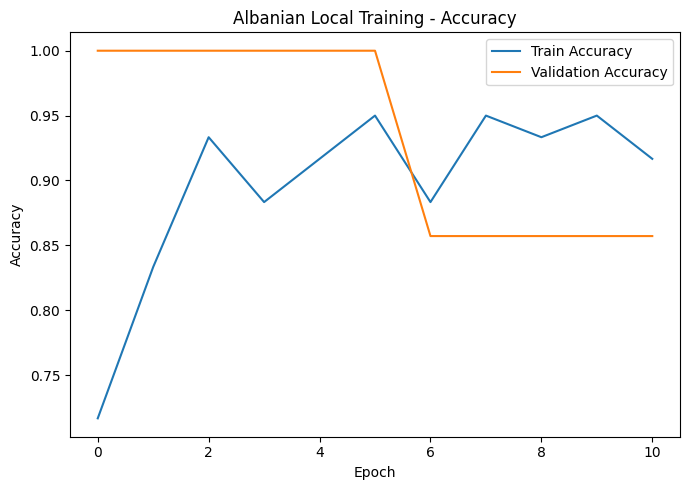

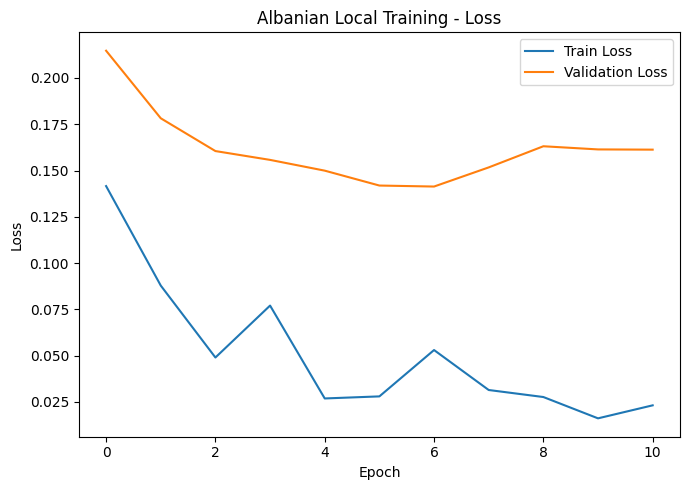

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(hist_df["accuracy"], label="Train Accuracy")
plt.plot(hist_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Albanian Local Training - Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "albanian_local_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(hist_df["loss"], label="Train Loss")
plt.plot(hist_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Albanian Local Training - Loss")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "albanian_local_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
y_test_prob = model.predict(X_test, verbose=0).ravel()
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
kappa = cohen_kappa_score(y_test, y_test_pred)

try:
    auc_score = roc_auc_score(y_test, y_test_prob)
except:
    auc_score = None

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

metrics = {
    "experiment": "Albanian localized training and testing",
    "threshold": THRESHOLD,
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1": float(f1),
    "kappa": float(kappa),
    "roc_auc": float(auc_score) if auc_score is not None else None,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "runtime_sec": round(runtime_sec, 2)
}

with open(EXP_ROOT / "metrics" / "albanian_local_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

print(json.dumps(metrics, indent=4))
print(classification_report(y_test, y_test_pred, target_names=["Non-Melanoma", "Melanoma"], zero_division=0))

{
    "experiment": "Albanian localized training and testing",
    "threshold": 0.55,
    "accuracy": 0.7777777777777778,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "kappa": -0.125,
    "roc_auc": 0.8125,
    "tn": 7,
    "fp": 1,
    "fn": 1,
    "tp": 0,
    "runtime_sec": 2.7
}
              precision    recall  f1-score   support

Non-Melanoma       0.88      0.88      0.88         8
    Melanoma       0.00      0.00      0.00         1

    accuracy                           0.78         9
   macro avg       0.44      0.44      0.44         9
weighted avg       0.78      0.78      0.78         9



In [17]:
pred_df = pd.DataFrame({
    "image_name": test_df["image_name"].values,
    "true_label": y_test,
    "pred_prob": y_test_prob,
    "pred_label": y_test_pred
})

pred_df.to_csv(EXP_ROOT / "predictions" / "albanian_local_test_predictions.csv", index=False)
pred_df.to_excel(EXP_ROOT / "predictions" / "albanian_local_test_predictions.xlsx", index=False)

display(pred_df)

,image_name,true_label,pred_prob,pred_label
0,image_052,0,0.044026,0
1,image_022,0,0.122455,0
2,image_061,0,0.032342,0
3,image_053,0,0.039565,0
4,image_076,1,0.122455,0
5,image_003,0,0.040812,0
6,image_021,0,0.716719,1
7,image_024,0,0.105988,0
8,image_015,0,0.080817,0


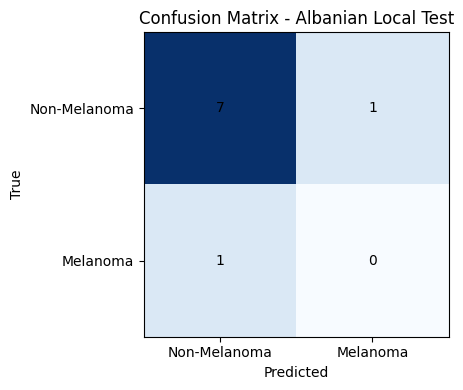

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))

labels = ["Non-Melanoma", "Melanoma"]

ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Albanian Local Test")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.savefig(EXP_ROOT / "confusion_matrix" / "albanian_local_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

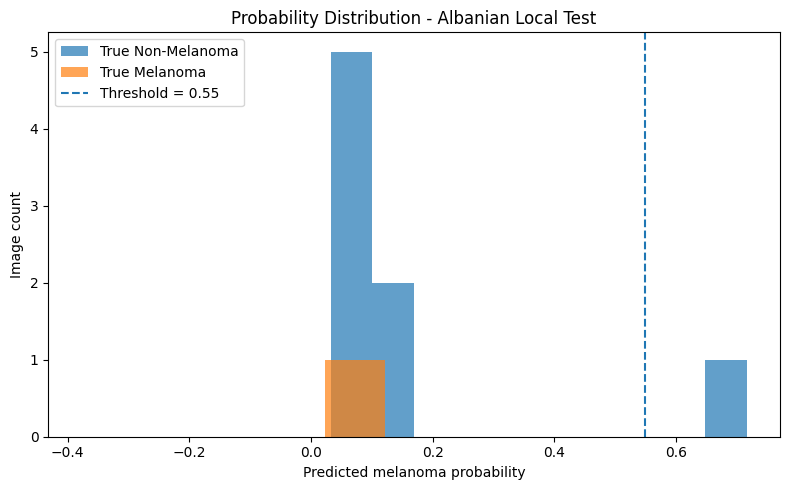

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(pred_df[pred_df["true_label"] == 0]["pred_prob"], bins=10, alpha=0.7, label="True Non-Melanoma")
plt.hist(pred_df[pred_df["true_label"] == 1]["pred_prob"], bins=10, alpha=0.7, label="True Melanoma")

plt.axvline(THRESHOLD, linestyle="--", label=f"Threshold = {THRESHOLD}")
plt.xlabel("Predicted melanoma probability")
plt.ylabel("Image count")
plt.title("Probability Distribution - Albanian Local Test")
plt.legend()
plt.tight_layout()
plt.savefig(EXP_ROOT / "plots" / "albanian_local_probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
manifest = {
    "experiment_name": "Localized Albanian Training and Testing",
    "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "input_folder": str(ALBANIAN_IMG_DIR),
    "metadata_file": str(ALBANIAN_METADATA),
    "output_folder": str(EXP_ROOT),
    "model": "ResNet50 frozen feature extractor + dense classifier",
    "split_strategy": "80/10/10 stratified train-validation-test split",
    "configurations_from_best_experiment": {
        "input_size": IMG_SIZE,
        "hair_removal": USE_HAIR_REMOVAL,
        "segmentation": USE_SEGMENTATION,
        "augmentation": AUG_MODE,
        "dense_units": DENSE_UNITS,
        "dropout": DROPOUT,
        "learning_rate": LR,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "threshold": THRESHOLD,
        "class_balanced_loss": True
    },
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "metrics": metrics
}

with open(EXP_ROOT / "summary" / "albanian_local_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4)

print("Localized Albanian experiment finished.")
print("All outputs saved under:", EXP_ROOT)

Localized Albanian experiment finished.
All outputs saved under: C:\Users\User\Desktop\Melanoma Detection Based on Deep Neural Networks Draft 01042026\19042026\Albanian_local_training_testing
